# Project Title

E-commerce Order Sales Analysis – Understanding Sales Performance, Customer Behaviour, and Delivery Trends

# **Objective(Problem statment)**

1. **To perform end-to-end exploratory data analysis (EDA) on real-world Airbnb listings data** — understanding the dataset's structure, size, columns, and data types before diving into deeper analysis.
2. **To clean and preprocess the raw, messy dataset** — handling missing values, removing duplicate listings, fixing inconsistent formats (price as text with $, percentage columns as strings, mixed date formats), and correcting invalid values (e.g., unrealistic minimum_nights or price = 0).
3. **To understand pricing patterns** — analyzing how price varies by neighbourhood, room type, and property type to identify what drives higher or lower nightly rates.
4. **To analyze host behavior** — studying host response rate, superhost status, and number of listings per host to understand how professional/multi-listing hosts differ from individual hosts.
5. **To study customer engagement through reviews** — examining number of reviews, review scores, and reviews-per-month to identify which listings/areas are most trusted and popular among guests.
6. **To create meaningful visualizations and derive actionable insights** — using univariate, bivariate, and multivariate analysis to explain pricing, host, and neighbourhood trends, and provide recommendations that support real business/host decisions.


# Outcome

The project helps uncover key patterns, trends, and hidden insights in e-commerce order data — such as which product categories drive the most revenue, which marketing channels and devices convert best, how delivery status affects the customer experience, and how sales change over time. The analysis provides a clear understanding of the data and supports data-driven decision-making for the business.

# Domain
Sales & E-commerce

#**Dataset Information**

**Source:** Hugging Face <font color="blue"><u> **[with link](https://huggingface.co/datasets/millat/e-commerce-orders)**</font></u>

**Year / Timeline:** Orders placed between April 2024 and April 2025

**Records / Features:** The full dataset on Hugging Face has 10,000 rows and 15 columns. For this project, a random sample of **1000 rows** was used (`ecommerce_orders_raw.csv`), which satisfies the minimum 500-record requirement and keeps the notebook fast to run while preserving the same 15 columns and data distribution as the original.

**Dataset Column/features Description:**

* **order_id** – Unique identifier for each order (UUID)
* **customer_id** – Unique identifier for the customer who placed the order
* **product_id** – Unique identifier for the product purchased
* **category** – Product category (Electronics, Clothing, Beauty, Home, Books, Toys)
* **price** – Unit price of the product (USD)
* **quantity** – Number of units ordered
* **order_date** – Timestamp when the order was placed
* **shipping_date** – Timestamp when the order was shipped
* **delivery_status** – Current status of the order (Delivered, Shipped, Returned, Pending)
* **payment_method** – Payment method used (Credit Card, Debit Card, PayPal, Apple Pay, Google Pay)
* **device_type** – Device used to place the order (Desktop, Mobile, Tablet)
* **channel** – Marketing channel that drove the order (Organic, Paid Search, Email, Social)
* **shipping_address** – Full shipping address of the customer
* **billing_address** – Full billing address of the customer
* **customer_segment** – Customer type (New, Returning, VIP)

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection


**COMPLETED**

* Define the business problem and expected outcome

* Choose dataset and explain its source, size, and features

* Import libraries, load dataset

* Dataset description (rows, columns, features)

* Initial EDA (head, info, describe, shape, null checks, duplicate check)

# **Inital EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Maheswari-SubashBalan/Main-Project-Python-and-PowerBI/refs/heads/main/ecommerce_orders_raw.csv")
df.head()

,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,145f6e9c-2393-4fd4-a2ca-ea513dc7ae6e,13,376,Beauty,233.37,1.0,2024-06-17 14:59:58.897063,2024-06-18 14:59:58.897063,Shipped,Google Pay,Desktop,Paid Search,"9931 Romero Garden Suite 823, New Rachelshire,...","932 Jocelyn Dale, South Matthew, Minnesota 93545",VIP
1,fabeee77-bb36-47f9-9bc9-310e66093daf,1223,601,Home,329.50,1.0,2024-04-22 14:59:58.897063,2024-04-26 14:59:58.897063,Delivered,Apple Pay,Tablet,Email,"029 Scott Passage Apt. 749, Davisville, Wiscon...","4950 Ryan Ford Suite 835, East Donaldmouth, Co...",VIP
2,49a1ae7a-ceea-42ce-a86d-b676bc2e086b,900,240,Books,371.66,3.0,2024-09-16 14:59:58.897063,2024-09-23 14:59:58.897063,Shipped,PayPal,Desktop,Organic,"5378 Green Locks, North Mollymouth, Florida 98089","47448 Davis Station, South Cynthiachester, Ark...",Returning
3,28128977-bdd1-40c4-a7cc-9a97fc1d84f7,97,168,Electronics,443.02,3.0,2025-03-20 14:59:58.897063,2025-03-26 14:59:58.897063,Delivered,Debit Card,Desktop,Organic,"813 Ashley Crossroad Suite 668, New Christinel...","722 Patricia Extension Suite 239, Josephberg, ...",Returning
4,a1a93ce7-c99c-42b0-85f1-db31cc40ff84,1636,455,Electronics,38.31,1.0,2024-12-25 14:59:58.897063,2025-01-01 14:59:58.897063,Shipped,Credit Card,Desktop,Organic,"1653 William Brooks, South Jerrystad, Idaho 96686","976 Hall Brooks Apt. 557, Jasonmouth, New Jers...",VIP


We loaded the raw CSV with Pandas. `df.head()` shows a mix of numeric columns (`price`, `quantity`), categorical columns (`category`, `delivery_status`, `payment_method`, `device_type`, `channel`, `customer_segment`), ID columns, timestamp columns, and free-text address columns.

In [ ]:
# Shape of the dataset
print("Rows, columns:",df.shape)

Rows, columns: (1000, 15)


In [ ]:
# Column datatypes and non null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1000 non-null   object 
 1   customer_id       1000 non-null   int64  
 2   product_id        1000 non-null   int64  
 3   category          985 non-null    object 
 4   price             985 non-null    float64
 5   quantity          990 non-null    float64
 6   order_date        1000 non-null   object 
 7   shipping_date     980 non-null    object 
 8   delivery_status   985 non-null    object 
 9   payment_method    985 non-null    object 
 10  device_type       1000 non-null   object 
 11  channel           1000 non-null   object 
 12  shipping_address  1000 non-null   object 
 13  billing_address   1000 non-null   object 
 14  customer_segment  1000 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 117.3+ KB


In [ ]:
#Statistical summary of numerical columns
df.describe()

,customer_id,product_id,price,quantity
count,1000.00000,1000.000000,985.000000,990.000000
mean,973.79800,510.465000,259.387797,2.072727
std,889.65301,284.068815,140.456109,1.218647
min,1.00000,1.000000,5.340000,1.000000
25%,161.75000,267.500000,138.950000,1.000000
50%,696.50000,526.000000,270.690000,2.000000
75%,1631.50000,747.250000,375.980000,3.000000
max,2996.00000,1000.000000,499.230000,9.000000


In [ ]:
#statistical summary of categorical columns
df.describe(include="object")

,order_id,category,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
count,1000,985,1000,980,985,985,1000,1000,1000,1000,1000
unique,900,6,332,344,4,5,3,4,900,900,3
top,fef2e4e7-85aa-44ea-b5c6-28a5d9109f07,Toys,2024-11-28 14:59:58.897063,2024-07-27 14:59:58.897063,Delivered,Debit Card,Desktop,Organic,"237 Shepherd Plaza, East Michael, Georgia 98144","3229 Thomas Heights, Kevinburgh, Arizona 17616",VIP
freq,2,180,9,8,676,213,361,268,2,2,522


In [ ]:
# check for missing value in all columns
df.isnull().sum().sort_values(ascending=False)

,0
shipping_date,20
price,15
category,15
delivery_status,15
payment_method,15
quantity,10
product_id,0
order_date,0
order_id,0
customer_id,0


In [ ]:
# check duplicated rows
print("Duplicated Rows:",df.duplicated().sum())
df[df.duplicated()].head()

Duplicated Rows: 80


,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
76,7b151c90-08e7-4bad-811d-370869568c7a,125,653,Beauty,180.57,2.0,2024-09-28 14:59:58.897063,2024-10-03 14:59:58.897063,Shipped,Google Pay,Desktop,Paid Search,"7929 Daniel Mountains, Ryanshire, Alaska 79757","48048 Green Islands, Lake Cassandra, Minnesota...",VIP
112,133d1546-44e6-4a5e-9ad7-7f92a61c90db,1,933,Electronics,372.78,1.0,2024-07-04 14:59:58.897063,2024-07-06 14:59:58.897063,Delivered,Google Pay,Mobile,Paid Search,"277 Taylor Parkway, New Andreside, Georgia 14413","855 Thomas Rue Suite 484, Hudsonbury, New Hamp...",VIP
113,180d0cda-b0a3-4d38-93d8-782572da27e1,2552,186,Clothing,126.19,3.0,2025-02-15 14:59:58.897063,2025-02-17 14:59:58.897063,Shipped,Apple Pay,Mobile,Email,"01745 Scott Harbors Apt. 716, North Dalemouth,...","3052 Gregory Vista, Terriville, West Virginia ...",Returning
147,9bfe359b-1b30-4bbe-9f44-0e38ecc6ba46,1947,585,Beauty,274.13,4.0,2025-01-16 14:59:58.897063,2025-01-22 14:59:58.897063,Delivered,Apple Pay,Desktop,Paid Search,"388 Gibson Groves, North Rachel, Mississippi 5...","223 Pierce Creek Suite 648, New Steventon, Vir...",Returning
156,eab09c32-8e42-4cfa-8e38-cb77292c3f2d,600,941,Home,107.29,1.0,2024-07-15 14:59:58.897063,2024-07-22 14:59:58.897063,Delivered,Debit Card,Mobile,Organic,"638 John Creek Apt. 952, Port Victoria, Indian...","2868 Bryan Run Suite 396, East Michaeltown, Te...",Returning


**Observations from Initial EDA:**

* The dataset has 1000 rows and 15 columns before cleaning.
* `category`, `price`, `quantity`, `delivery_status`, `payment_method` and `shipping_date` each contain a small number of missing values (roughly 1–2% of rows).
* There are duplicate rows in the raw data that need to be removed before analysis.
* `order_date` and `shipping_date` are stored as text and need to be converted to datetime.
* `shipping_address` / `billing_address` are free text — useful information like the customer's **state** can be extracted from them for regional analysis.

## Stage 2 – Data Cleaning and Pre-processing

- Handle missing values (impute or drop)

- Handle duplicates
- column name rename or dropping unwanted columns if required

- Treat outliers if required

- Check skewness and apply transformations

- Convert data types if needed

- Feature transformations (date parts, derived fields if required for analysis)

In [ ]:
# create a copy of the original dataset for cleaning
df_clean = df.copy()
df_clean.shape

(1000, 15)

In [ ]:
#Remove duplicates
print("Duplicates:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()
print("After Remove duplicates data:",df_clean.shape)

Duplicates: 80
After Remove duplicates data: (920, 15)


In [ ]:
#convert to datetime for "order_date" and "shipping_date"
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"],errors="coerce")

df_clean["shipping_date"] = pd.to_datetime(df_clean["shipping_date"],errors="coerce")

print(df_clean[["order_date","shipping_date"]].dtypes)
print(df_clean["order_date"])

order_date       datetime64[ns]
shipping_date    datetime64[ns]
dtype: object
0     2024-06-17 14:59:58.897063
1     2024-04-22 14:59:58.897063
2     2024-09-16 14:59:58.897063
3     2025-03-20 14:59:58.897063
4     2024-12-25 14:59:58.897063
                 ...            
995   2024-04-22 14:59:58.897063
996   2025-03-12 14:59:58.897063
997   2024-08-03 14:59:58.897063
998   2025-04-13 14:59:58.897063
999   2025-03-06 14:59:58.897063
Name: order_date, Length: 920, dtype: datetime64[ns]


In [ ]:
#Handle missng values (category,price,quantity,shipping date,delivery status,payment method)

#categorical columns (Category, delivery status, payment method) - take with mode

for colu in ["category", "delivery_status", "payment_method"]:
    df_clean[colu] = df_clean[colu].fillna(df_clean[colu].mode()[0])

#numerical columns (price, quantity) - take with median

df_clean["price"] = df_clean["price"].fillna(df_clean["price"].median())

df_clean["quantity"] = df_clean["quantity"].fillna(df_clean["quantity"].median())
df_clean["quantity"] = df_clean["quantity"].astype(int)

# Filling Shipping Date for Non-Pending Orders
median_fill = (df_clean["shipping_date"]-df_clean["order_date"]).median()
missing_shipping = (df_clean["shipping_date"].isna()& (df_clean['delivery_status']!="Pending"))

df_clean.loc[missing_shipping,"shipping_date"] = df_clean.loc[missing_shipping,"order_date"] + median_fill


print(df_clean.isnull().sum())

order_id            0
customer_id         0
product_id          0
category            0
price               0
quantity            0
order_date          0
shipping_date       1
delivery_status     0
payment_method      0
device_type         0
channel             0
shipping_address    0
billing_address     0
customer_segment    0
dtype: int64


1 remaining null in shipping_date belongs to a "Pending" order (order not yet shipped).
This is expected and correct — we intentionally leave it as NaT (Not a Time)
since a pending order cannot have a shipping date yet.

In [ ]:
#Total order value
df_clean["total_amount"] = df_clean["price"] * df_clean["quantity"]

#Trend analysis extract with month and weekday
df_clean["order_month"] = df_clean["order_date"].dt.to_period("M").astype(str)
df_clean["order_year"] = df_clean["order_date"].dt.year
df_clean["order_weekday"] = df_clean["order_date"].dt.day_name()

#shipping date delay
df_clean["shipping_delay_days"] = (df_clean["shipping_date"] - df_clean["order_date"]).dt.days


print(df_clean[['price', 'quantity', 'total_amount', 'order_date', 'shipping_delay_days']].head())

    price  quantity  total_amount                 order_date  \
0  233.37         1        233.37 2024-06-17 14:59:58.897063   
1  329.50         1        329.50 2024-04-22 14:59:58.897063   
2  371.66         3       1114.98 2024-09-16 14:59:58.897063   
3  443.02         3       1329.06 2025-03-20 14:59:58.897063   
4   38.31         1         38.31 2024-12-25 14:59:58.897063   

   shipping_delay_days  
0                  1.0  
1                  4.0  
2                  7.0  
3                  6.0  
4                  7.0  


In [ ]:
#billing address column drop
df_clean = df_clean.drop(columns=["billing_address"])

In [ ]:
#finally check the cleaning data
print("Final Shape:",df_clean.shape)
print("Total Nulls:",df_clean.isnull().sum().sum())
df_clean.info()
df_clean.head()

Final Shape: (920, 19)
Total Nulls: 2
<class 'pandas.core.frame.DataFrame'>
Index: 920 entries, 0 to 999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             920 non-null    object        
 1   customer_id          920 non-null    int64         
 2   product_id           920 non-null    int64         
 3   category             920 non-null    object        
 4   price                920 non-null    float64       
 5   quantity             920 non-null    int64         
 6   order_date           920 non-null    datetime64[ns]
 7   shipping_date        919 non-null    datetime64[ns]
 8   delivery_status      920 non-null    object        
 9   payment_method       920 non-null    object        
 10  device_type          920 non-null    object        
 11  channel              920 non-null    object        
 12  shipping_address     920 non-null    object        
 13  cu

,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,customer_segment,total_amount,order_month,order_year,order_weekday,shipping_delay_days
0,145f6e9c-2393-4fd4-a2ca-ea513dc7ae6e,13,376,Beauty,233.37,1,2024-06-17 14:59:58.897063,2024-06-18 14:59:58.897063,Shipped,Google Pay,Desktop,Paid Search,"9931 Romero Garden Suite 823, New Rachelshire,...",VIP,233.37,2024-06,2024,Monday,1.0
1,fabeee77-bb36-47f9-9bc9-310e66093daf,1223,601,Home,329.50,1,2024-04-22 14:59:58.897063,2024-04-26 14:59:58.897063,Delivered,Apple Pay,Tablet,Email,"029 Scott Passage Apt. 749, Davisville, Wiscon...",VIP,329.50,2024-04,2024,Monday,4.0
2,49a1ae7a-ceea-42ce-a86d-b676bc2e086b,900,240,Books,371.66,3,2024-09-16 14:59:58.897063,2024-09-23 14:59:58.897063,Shipped,PayPal,Desktop,Organic,"5378 Green Locks, North Mollymouth, Florida 98089",Returning,1114.98,2024-09,2024,Monday,7.0
3,28128977-bdd1-40c4-a7cc-9a97fc1d84f7,97,168,Electronics,443.02,3,2025-03-20 14:59:58.897063,2025-03-26 14:59:58.897063,Delivered,Debit Card,Desktop,Organic,"813 Ashley Crossroad Suite 668, New Christinel...",Returning,1329.06,2025-03,2025,Thursday,6.0
4,a1a93ce7-c99c-42b0-85f1-db31cc40ff84,1636,455,Electronics,38.31,1,2024-12-25 14:59:58.897063,2025-01-01 14:59:58.897063,Shipped,Credit Card,Desktop,Organic,"1653 William Brooks, South Jerrystad, Idaho 96686",VIP,38.31,2024-12,2024,Wednesday,7.0


## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

**Interpretation MUST with every visualization**

Focus on business story not just charts

Each chart must be in seperate cells.

# **Note For Kind of Analysis to be done**

**Type of Analysis**

* Descriptive Analysis (summarizing the dataset)

* Diagnostic Analysis (finding reasons behind patterns)

* Predictive Analysis (optional if forecasting required using basic stats)

* Prescriptive Analysis (recommendations for business decisions)

### Analysis about Monthly Sales Trend / Revenue by Channel

### **Insights**

- VIP customers contribute the highest total revenue across most product categories.
- Electronics and Beauty are among the top categories by order volume.
- Majority of orders are successfully Delivered; Returned and Pending orders need monitoring.
- There is no strong correlation between Price and Quantity.
- Monthly revenue shows clear ups and downs (seasonality).
- Total Amount is strongly driven by both Price and Quantity.
- Shipping delay has almost no relationship with order value.

## Interpretation of countplot chart

Explain the Chart.

**--** This is a grouped bar chart (countplot) showing the number of orders in each product category, further split by delivery status.

What is it saying?

**--** It shows both the popularity of each category and how delivery performance (Delivered, Shipped, Returned, Pending) is distributed within each category.

What features you used?

*    `category` (categorical)
*    `delivery_status` (categorical – used as hue)

From this what you are showing us?

**--** We can see which categories have higher order volume and whether any category has unusually high Returned or Pending orders. This helps identify categories that need operational attention along with volume leaders.

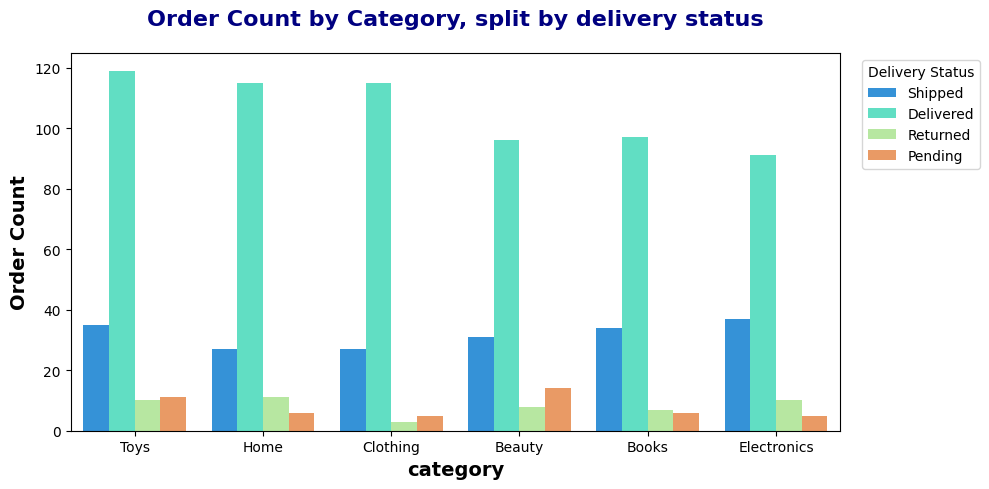

In [ ]:
#Countplot chart

plt.figure(figsize=(10,5))
sns.countplot(data=df_clean,
              x="category",
              order=df_clean["category"].value_counts().index,
              palette="rainbow",
              hue="delivery_status")
plt.title("Order Count by Category, split by delivery status",fontsize=16,color="navy",weight="bold",pad=20)
plt.xlabel("category",size=14,weight="bold")
plt.ylabel("Order Count",size=14,weight="bold")
plt.xticks(rotation=0)
plt.legend(title="Delivery Status",bbox_to_anchor=(1.02, 1),loc='upper left')
plt.tight_layout()
plt.show()

## Interpretation of Pie chart

Explain the Chart.

**--** This is a pie chart showing the percentage distribution of different delivery statuses in the dataset.

What is it saying?

**--** The majority of orders are in “Delivered” status. Shipped, Returned and Pending make up smaller portions of the total orders.

What features you used?

*   `delivery_status` (categorical)

From this what you are showing us?

**--** Overall delivery performance is healthy. However, the Returned and Pending percentages should be monitored closely to reduce cancellations/returns and improve customer satisfaction.

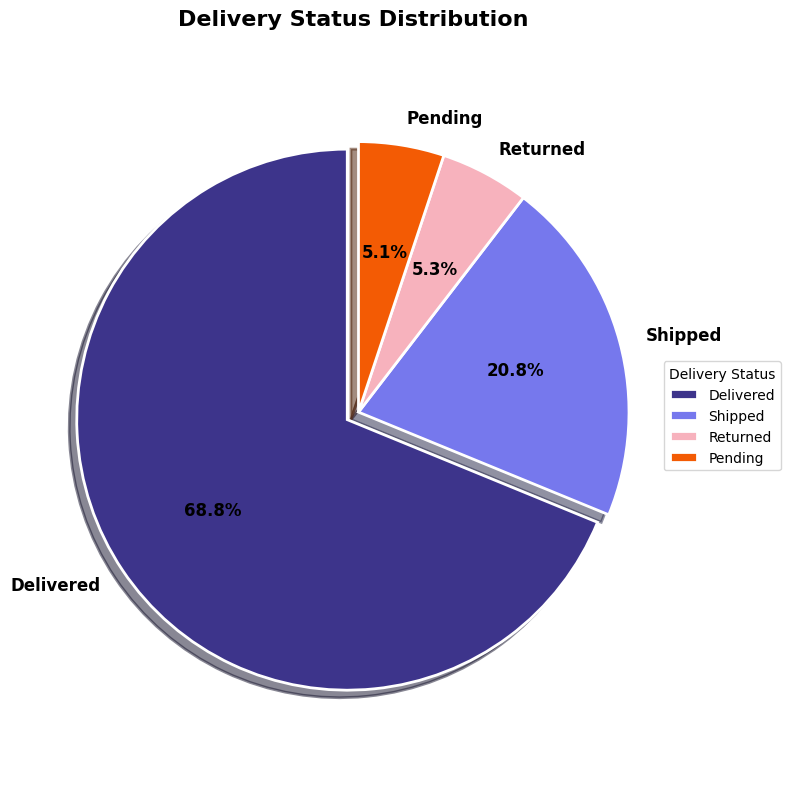

In [ ]:
#Pie chart

status_counts = df_clean["delivery_status"].value_counts()
plt.figure(figsize=(8,8))
colors = ['#3D348B', '#7678ED', '#F7B2BD', '#F35B04']
explode = [0.05, 0, 0, 0]
plt.pie(status_counts.values,
        labels=status_counts.index,
        autopct="%1.1f%%",
        colors=colors,
        explode=explode,
        startangle=90,
        shadow=True,
        wedgeprops={"edgecolor":"white","linewidth":2 },
        textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'}
)
plt.title("Delivery Status Distribution", fontsize=16, fontweight="bold",pad=20)

plt.legend(status_counts.index,
           title="Delivery Status",
           loc="center left",
           fontsize=10,
           bbox_to_anchor=(1,0.5))
plt.axis("equal")
plt.tight_layout()
plt.show()

## Interpretation of Clustered Bar Chart chart

Explain the Chart.

**--** This is a clustered (grouped) bar chart showing total revenue generated by each product category, further split by customer segment (VIP, Returning, New).

What is it saying?

**--** It shows which category + customer segment combination generates the highest revenue. VIP customers contribute the most across most categories.

What features you used?

*   `category` (categorical)
*   `customer_segment` (categorical – used as hue)
*   `total_amount` (numerical – aggregated using sum)

From this what you are showing us?

**--** We can identify the most profitable category-segment combinations. This helps in targeting high-value customers with relevant product categories and designing segment-specific marketing strategies.

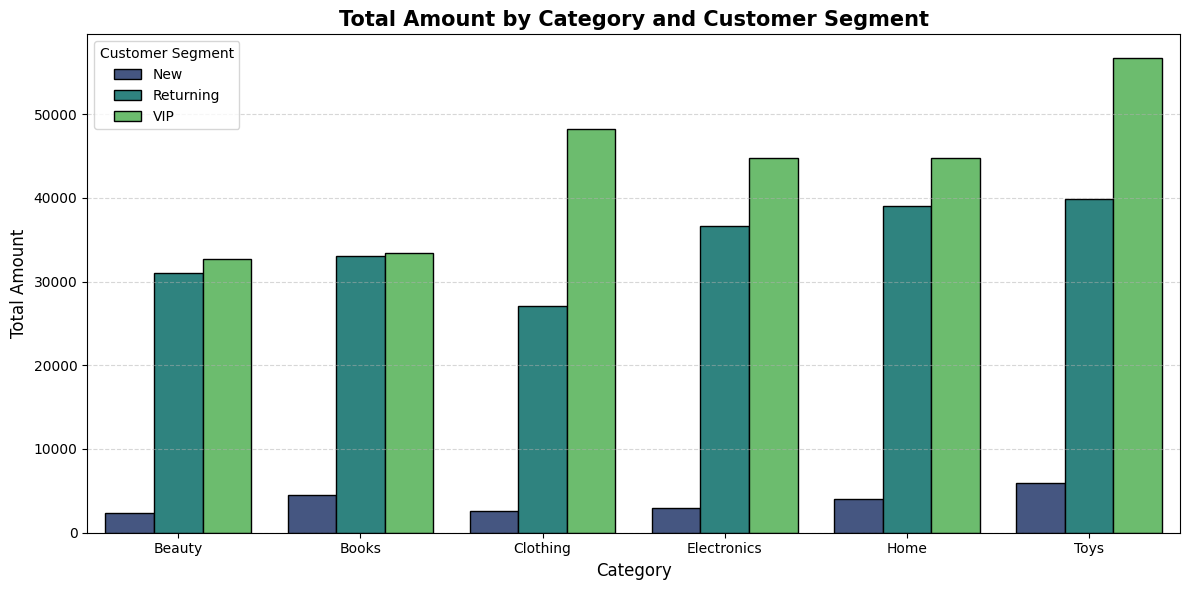

In [ ]:
groupby_df = df_clean.groupby(["category","customer_segment"])["total_amount"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=groupby_df,
            x = "category",
            y = "total_amount",
            hue = "customer_segment",
            palette="viridis",
            edgecolor="black")

plt.title("Total Amount by Category and Customer Segment", fontsize=15, fontweight= "bold")
plt.xlabel("Category",fontsize=12)
plt.ylabel("Total Amount",fontsize=12)
plt.xticks(fontsize=10)
plt.legend(title="Customer Segment")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.tight_layout()
plt.show()

## Interpretation of Line chart

Explain the Chart.

**--** This is a line chart showing the total revenue generated in each month (1 = January to 12 = December).

What is it saying?

**--** Revenue fluctuates across months. Some months show higher revenue while others are relatively lower, indicating seasonal variation.

What features you used?

*   `order_month` (numerical – derived from order_date)
*   `total_amount` (numerical – aggregated using sum)

From this what you are showing us?

**--** There is a clear monthly trend in revenue. Peak months can be used for better inventory planning and targeted marketing campaigns.

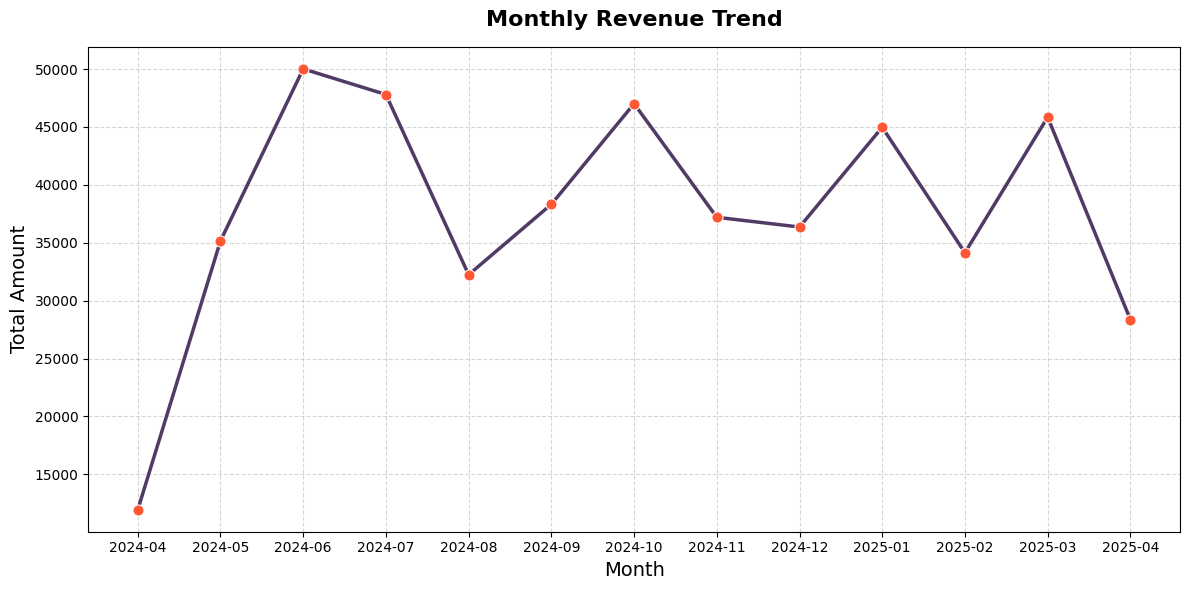

In [ ]:
monthly_revenue = df_clean.groupby("order_month")["total_amount"].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values("order_month")

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_revenue,
             x="order_month",
             y="total_amount",
             marker="o",
             markersize=8,
             markerfacecolor="#FF5733",
             markeredgecolor="white",
             linewidth=2.5,
             color="#513b66")
plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Total Amount", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

##Interpretation of Histrogram chart
Explain the Chart.

**--** This is a line chart showing the total revenue generated in each month (1 = January to 12 = December).

What is it saying?

**--** Revenue fluctuates across months. Some months show higher revenue while others are relatively lower, indicating seasonal variation.

What features you used?

*   `order_month` (numerical – derived from order_date)
*   `total_amount` (numerical – aggregated using sum)

From this what you are showing us?

**--** There is a clear monthly trend in revenue. Peak months can be used for better inventory planning and targeted marketing campaigns.

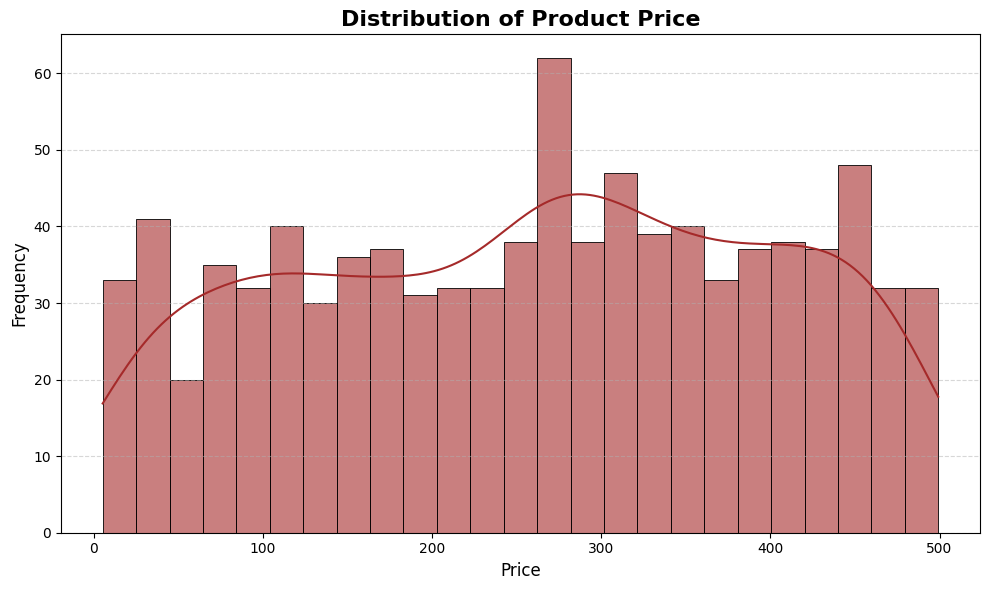

count    920.000000
mean     259.626293
std      139.284202
min        5.340000
25%      142.807500
50%      269.350000
75%      375.305000
max      499.230000
Name: price, dtype: float64


In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean["price"],
             bins=25,
             kde=True,
             color="brown",
             edgecolor="black",
             linewidth=0.6,
             alpha=0.6)

plt.title("Distribution of Product Price", fontsize=16, fontweight="bold")
plt.xlabel("Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--",alpha=0.5)
plt.tight_layout()
plt.show()

print(df_clean["price"].describe())

## Interpretation of your above chart

Explain the Chart.

**--** These are boxplots showing the distribution of quantity per order before and after outlier treatment using the IQR method.

What is it saying?

**--** Before treatment, a few orders have unusually high quantities. After clipping, extreme values are capped within the acceptable range.

What features/columns you used?

**-** `quantity` (numerical)

From this what you are showing us?

**--** We identified and treated extreme quantity values so that they do not heavily influence average calculations and visualizations. This makes the analysis more stable.

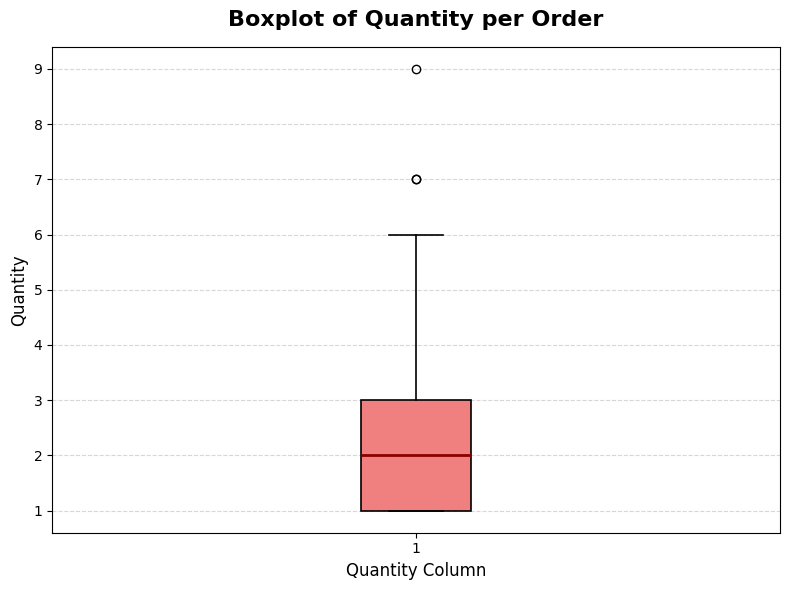

count    920.000000
mean       2.067391
std        1.223555
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        9.000000
Name: quantity, dtype: float64


In [ ]:
#Before Outlier
plt.figure(figsize=(8, 6))

plt.boxplot(df_clean["quantity"], vert=True, patch_artist=True,
            boxprops=dict(facecolor="lightcoral", edgecolor="black", linewidth=1.2),
            medianprops=dict(color="darkred", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1.2),
            capprops=dict(color="black", linewidth=1.2))

plt.title("Boxplot of Quantity per Order", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Quantity Column", fontsize=12)
plt.ylabel("Quantity", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(df_clean["quantity"].describe())

In [ ]:
#check maximum quantity
print("Max quantity:", df_clean["quantity"].max())

Max quantity: 9


In [ ]:
#Handle Outlieers for quantity column

q1_q = df_clean["quantity"].quantile(0.25)
q3_q = df_clean["quantity"].quantile(0.75)
iqr_q = q3_q - q1_q
lower_q = q1_q - 1.5*iqr_q
upper_q = q3_q + 1.5*iqr_q
df_clean["quantity"] = df_clean["quantity"].clip(lower=lower_q, upper=upper_q).round().astype(int)

print("After clipping - Max quantity:", df_clean["quantity"].max())

After clipping - Max quantity: 6


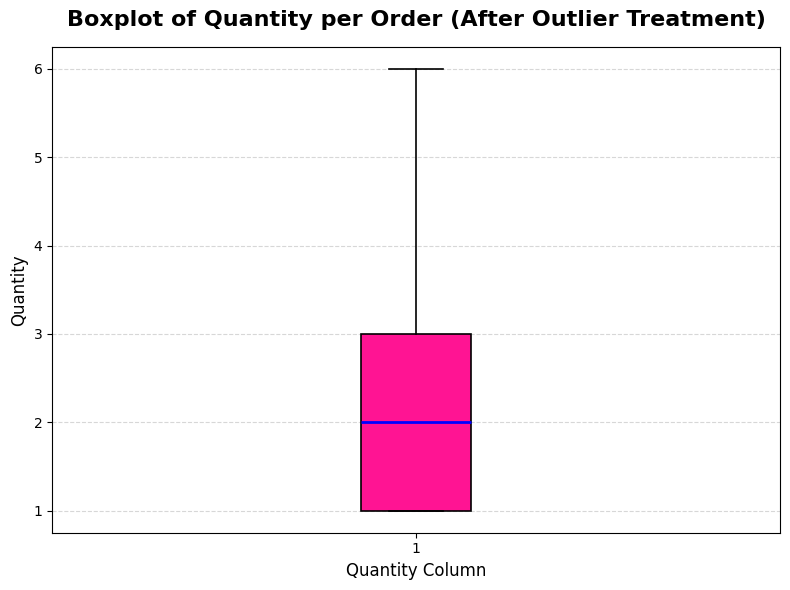

In [ ]:
#After handling the outliers
plt.figure(figsize=(8, 6))

plt.boxplot(df_clean["quantity"], vert=True, patch_artist=True,
            boxprops=dict(facecolor="deeppink", edgecolor="black", linewidth=1.2),
            medianprops=dict(color="blue", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1.2),
            capprops=dict(color="black", linewidth=1.2))

plt.title("Boxplot of Quantity per Order (After Outlier Treatment)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Quantity Column", fontsize=12)
plt.ylabel("Quantity", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

##Interpretation of Correlation heatmap chart
Explain the Chart.

**--** This is a correlation heatmap showing the relationship between numerical features: price, quantity, total_amount and shipping_delay_days.

What is it saying?

**--** `total_amount` has strong positive correlation with both `price` and `quantity` (expected, because total = price × quantity).  
**--** `shipping_delay_days` has almost no correlation with other features.  
**--** `price` and `quantity` are almost independent of each other.

What features/columns you used?

**-** `price`, `quantity`, `total_amount`, `shipping_delay_days` (all numerical)

From this what you are showing us?

**--** Total order value is mainly driven by price and quantity. Shipping delay does not depend on order value or quantity, which means operational delay is independent of order size.

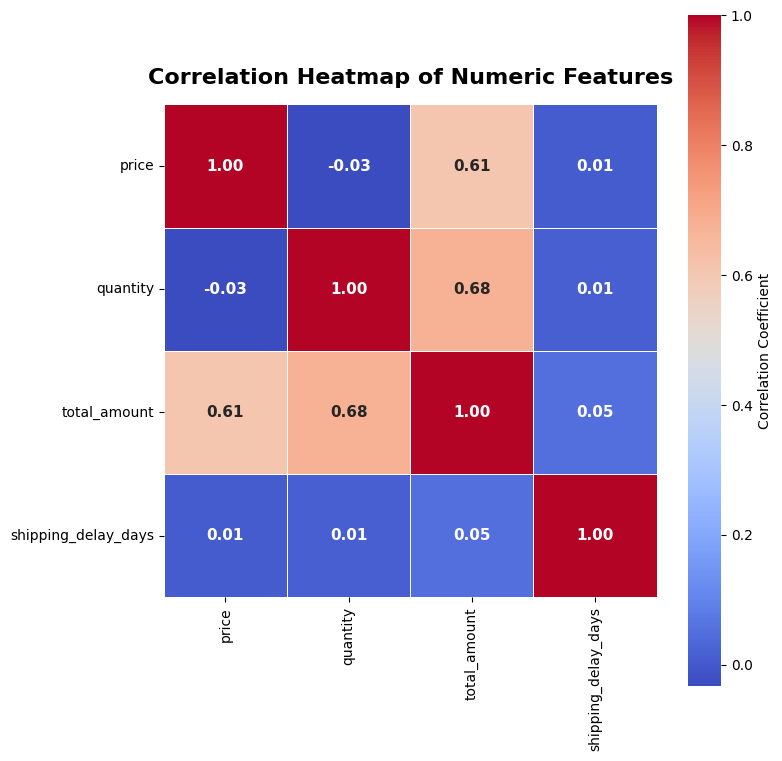

In [ ]:
corr_columns = ["price", "quantity", "total_amount", "shipping_delay_days"]
corr_matrix = df_clean[corr_columns].corr()

plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Correlation Coefficient"},
            annot_kws={"fontsize": 11, "fontweight": "bold"})

plt.title("Correlation Heatmap of Numeric Features", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation of Scatter chart

Explain the Chart.

**--** This is a scatterplot showing the relationship between Price and Quantity, with points colored by product category.

What is it saying?

**--** There is no strong linear relationship between price and quantity. Orders are spread across different price and quantity combinations. Some categories appear more in higher price ranges, while others are concentrated in lower price ranges.

What features you used?

- `price` (numerical)  
- `quantity` (numerical)  
- `category` (categorical – used as hue)

From this what you are showing us?

**--** Price and quantity are largely independent. Customers buy both low-priced and high-priced products in varying quantities. Category-wise colouring helps identify which categories dominate different price-quantity zones.

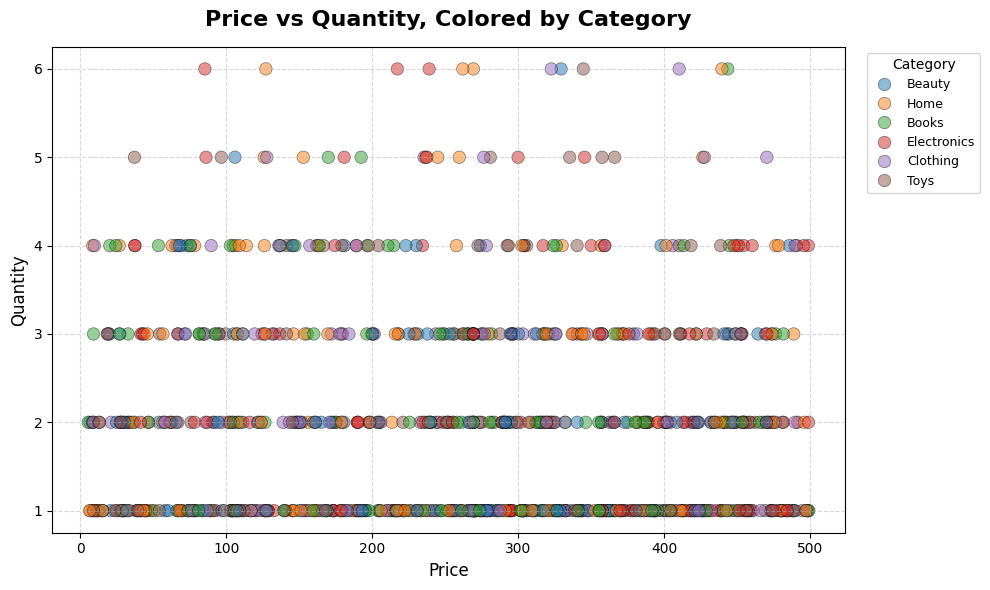

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="price",
                y="quantity",
                hue="category",
                palette="tab10",
                alpha=0.5,
                s=80,
                edgecolor="black",
                linewidth=0.5)

plt.title("Price vs Quantity, Colored by Category", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Price", fontsize=12)
plt.ylabel("Quantity", fontsize=12)
plt.legend(title="Category", fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Interpretation of Area chart

*   List item
*   List item



Explain the Chart.

**--** This is an area chart (with line) showing the total revenue for each month from April 2024 to April 2025.

What is it saying?

**--** Revenue varies across months. Some months show clear peaks while others are lower, indicating seasonality in sales.

What features you used?

- `order_date` (datetime – converted to month)  
- `total_amount` (numerical – aggregated using sum)

From this what you are showing us?

**--** Monthly revenue trend helps identify strong and weak months. This information is useful for inventory planning, promotions, and sales forecasting.

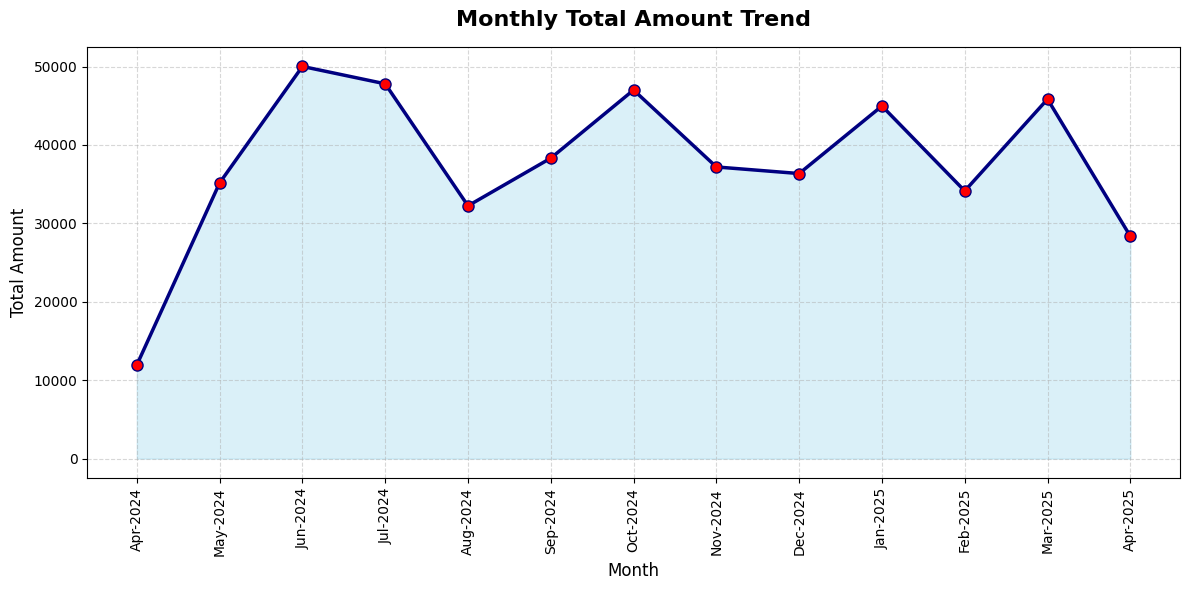

In [ ]:
df_clean ["month_sort"] = df_clean["order_date"].dt.to_period("M")
df_clean ["month_name"] = df_clean["order_date"].dt.strftime("%b-%Y")

month_data = df_clean.groupby(["month_sort","month_name"])["total_amount"].sum().reset_index()
month_data = month_data.sort_values("month_sort")

plt.figure(figsize=(12,6))
plt.fill_between(month_data["month_name"],month_data["total_amount"],
                 color="skyblue", alpha=0.3)
plt.plot(month_data["month_name"],
         month_data["total_amount"],
         color="navy", linewidth=2.5, marker="o", markersize=8,
         markerfacecolor="red")
plt.title("Monthly Total Amount Trend", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Amount", fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## **Steps to Download your cleaned data for dashboard creation using Power BI**


In [ ]:
# Cleaned dataset save
df_clean.to_csv("ecommerce_orders_cleaned.csv", index=False)

print("Shape:", df_clean.shape)
print("Nulls:", df_clean.isnull().sum().sum())
print("Columns:", df_clean.columns.tolist())

Shape: (920, 21)
Nulls: 2
Columns: ['order_id', 'customer_id', 'product_id', 'category', 'price', 'quantity', 'order_date', 'shipping_date', 'delivery_status', 'payment_method', 'device_type', 'channel', 'shipping_address', 'customer_segment', 'total_amount', 'order_month', 'order_year', 'order_weekday', 'shipping_delay_days', 'month_sort', 'month_name']


## Stage 4 – Documentation, Insights and Presentation

Show a dashboard aligning all the charts in powerbi by connecting python in PowerBI

Summarize findings in plain English (what do the patterns mean)

Highlight 3–5 key insights (trends, anomalies, correlations)

Provide recommendations for business or decision-making

Explain the FINAL STORY WITH THE DASHBOARD/report

Create a PDF pasting your DASHBOARD, explaining all the above mentioned concepts and submit it


# Dashboard 1

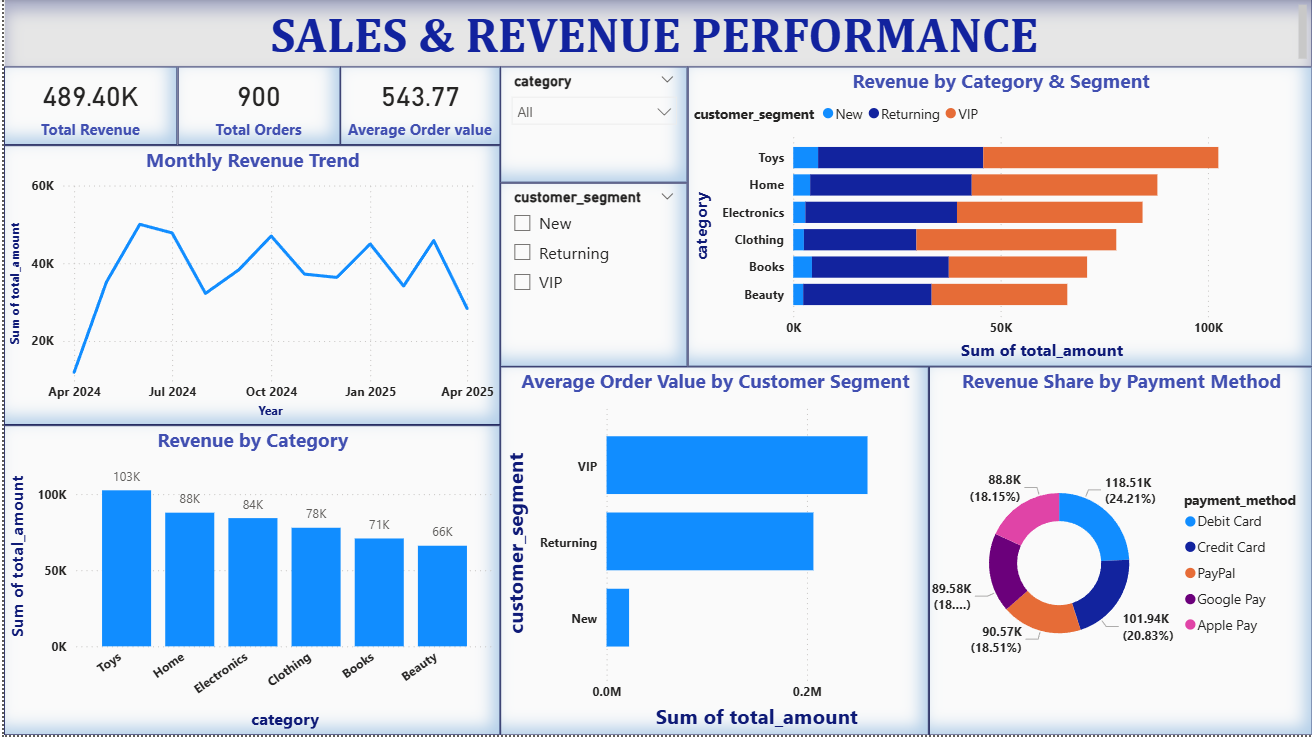

# Dashboard 2

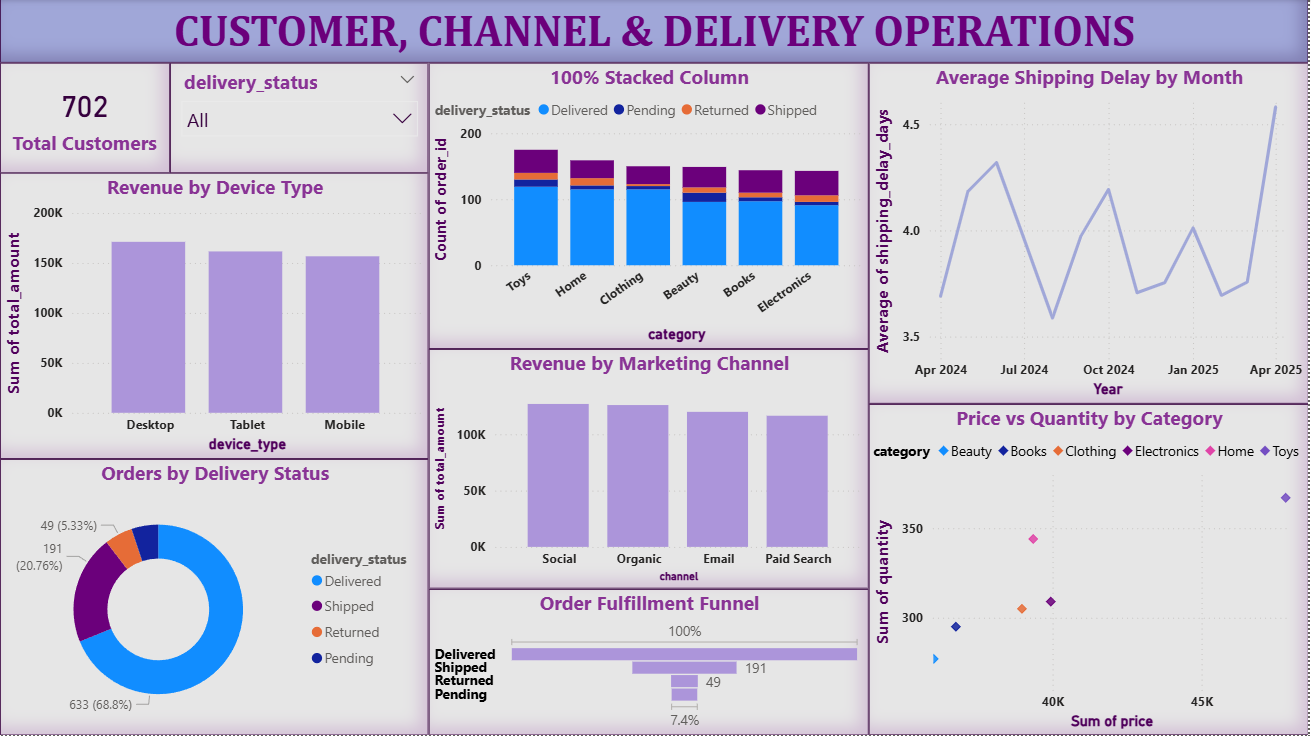

## Insights & Conclusions

### 1. Descriptive Analysis
- The cleaned dataset contains **900 orders** with total revenue of approximately **$489.40K**.
- **702 unique customers** placed orders across 6 product categories.
- **Delivered orders are the highest (68.8%)**, followed by Shipped, Returned, and Pending orders.
- Most orders contain **1–3 units**.

### 2. Diagnostic Analysis
- **Toys and Home** generate the highest revenue.
- **Beauty** has a similar order volume but lower revenue, indicating a lower average order value.
- **Returning and VIP customers** have a higher AOV than New customers.
- Revenue is mainly driven by **price and quantity**.

### 3. Predictive Analysis
- Monthly revenue shows a **seasonal pattern**, with a peak around June 2024.
- The return rate is around **5%**, which can help in planning future return volumes.

### 4. Recommendations
- Focus more marketing efforts on **Toys and Home**.
- Use **bundle offers** to increase Beauty sales.
- Provide first-order offers to **New customers** to improve their AOV.
- Plan inventory and staff based on **seasonal demand**.
- Monitor **returned orders** to identify possible product or quality issues.

### Conclusion
Overall, the analysis shows that **customer type, price, quantity, product category, and seasonal demand** have an important impact on revenue and business performance.

## Future Enhancements

* Build a **time-series forecasting model** such as ARIMA or Prophet to predict future sales.
* Analyse customer behaviour in more detail to improve **customer retention**.
* Monitor marketing channel performance and compare **ROI**.
* Analyse returned orders to identify **product or quality issues**.
* Use larger datasets to improve the accuracy and reliability of the analysis.


## Conclusion

* Python helped in **data cleaning, transformation, feature engineering, and EDA**.
* Power BI was used to create **interactive dashboards and KPIs**.
* The analysis helped identify **top-performing categories, valuable customer segments, sales trends, and delivery performance**.
* These insights can support better decisions in **marketing, customer retention, inventory planning, and operations**.

### Overall Conclusion

This project demonstrates how **Python and Power BI can be combined to transform raw e-commerce data into meaningful business insights and support data-driven decision-making.**

## **FINAL PROJECT GITHUB REPOSITORY:**

**REPO:** https://github.com/Maheswari-SubashBalan/Main-Project-Python-and-PowerBI